# Smart Attendance(privce first)
## AI3302 - Computer Vision Project



## Step 1 - Install and Import Libraries

In [ ]:
# Install required libraries quietly (-q reduces installation output)
!pip install ultralytics kagglehub opencv-python numpy pandas matplotlib -q


# Import essential libraries

import os                     # Handle file and directory operations
import cv2                    # OpenCV for image processing
import glob                   # Retrieve files using patterns
import time                   # Measure execution time
import random                 # Generate random values

import numpy as np            # Numerical computations (arrays, matrices)
import pandas as pd           # Data manipulation and analysis

import matplotlib.pyplot as plt       # Plot graphs and images
import matplotlib.patches as mpatches # Draw shapes like bounding boxes

from ultralytics import YOLO  # YOLO model for object detection
import kagglehub              # Download datasets from Kaggle


# Confirm libraries loaded

print("Libraries imported successfully")

# Display OpenCV version to verify installation
print("OpenCV version:", cv2.__version__)

# Check Python & PyTorch setup

import sys                    # Access system-specific parameters
import torch                  # PyTorch framework (used by YOLO)

# Print Python version
print(f"Python version: {sys.version}")

# Simple confirmation message
print("Are all libraries working? Yes")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported successfully
OpenCV version: 4.13.0
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Are all libraries working? Yes


## Step 2 - Download Dataset from Kaggle

Attempt 1/5: Downloading hoangxuanviet/scut-head ...


100%|██████████| 451M/451M [00:27<00:00, 17.1MB/s]

Extracting files...


Download complete: /root/.cache/kagglehub/datasets/hoangxuanviet/scut-head/versions/1
Dataset path: /root/.cache/kagglehub/datasets/hoangxuanviet/scut-head/versions/1/PartA
Total images found: 2000


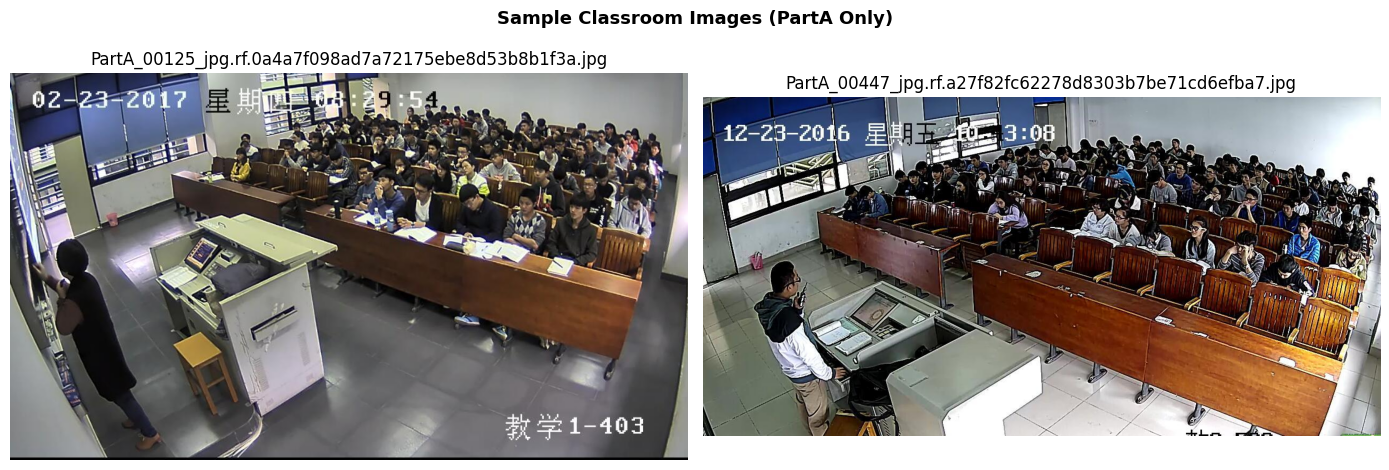

In [ ]:
import kagglehub
import os
import glob
import cv2
import time
import matplotlib.pyplot as plt


def download_with_retry(dataset, retries=5, wait=10):
    """
    Downloads a Kaggle dataset with retry mechanism in case of failure.

    Args:
        dataset (str): Kaggle dataset identifier
        retries (int): Number of retry attempts
        wait (int): Waiting time between retries (seconds)
    """

    # Try downloading multiple times in case of errors
    for attempt in range(1, retries + 1):
        try:
            print(f"Attempt {attempt}/{retries}: Downloading {dataset} ...")

            # Download dataset using kagglehub
            base = kagglehub.dataset_download(dataset)

            print("Download complete:", base)
            return base

        except Exception as e:
            print(f"  Error: {e}")

            # If not last attempt, wait before retrying
            if attempt < retries:
                print(f"  Retrying in {wait} seconds...")
                time.sleep(wait)
            else:
                # Raise error if all attempts fail
                raise RuntimeError(f"Failed after {retries} attempts.") from e



# Download dataset


base_path = download_with_retry("hoangxuanviet/scut-head")

# Define dataset working path (PartA folder)
path = os.path.join(base_path, "PartA")

print("Dataset path:", path)



# Load all images


# Recursively collect all .jpg images in dataset
all_images = glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True)

# Print total number of images found
print(f"Total images found: {len(all_images)}")



# Display sample images


# Create subplot for showing 2 sample images
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loop over 2 sample images (index 2 and 3)
for ax, ip in zip(axes, all_images[2:4]):

    # Read image using OpenCV
    img = cv2.imread(ip)

    # Skip if image cannot be loaded
    if img is None:
        continue

    # Convert BGR (OpenCV) to RGB (matplotlib)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    # Set image title as filename
    ax.set_title(os.path.basename(ip))

    # Hide axis
    ax.axis('off')

# Overall title for the figure
plt.suptitle("Sample Classroom Images (PartA Only)", fontsize=13, fontweight='bold')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show images
plt.show()

## Step 3 - Load Ground Truth Labels

In [ ]:
import os
import glob

# Define path to all YOLO label files (.txt)
labels_path = os.path.join(path, "**", "*.txt")

# Recursively collect all label files
txt_files = glob.glob(labels_path, recursive=True)

# Dictionary to store image name -> number of objects (ground truth)
gt_lookup = {}

# Print number of label files found
print(f"Processing {len(txt_files)} txt label files...")


# 2. Parse each label file

for txt_file in txt_files:

    # Skip any README or non-label files
    if "README" in txt_file:
        continue

    try:
        # Each line in YOLO label file represents one object (head)
        with open(txt_file, 'r') as f:
            lines = f.readlines()

            # Remove empty lines (safety check)
            valid_lines = [line for line in lines if line.strip()]

            # Count number of detected objects in ground truth
            head_count = len(valid_lines)

        # Convert label filename to corresponding image filename
        # Example: 001.txt -> 001.jpg
        file_basename = os.path.basename(txt_file).replace('.txt', '.jpg')

        # Store mapping: image -> number of heads
        gt_lookup[file_basename] = head_count

    except Exception as e:
        # Skip file if any error occurs (corrupted or unreadable file)
        continue



# 3. Summary output

print("Ground truth loaded:", len(gt_lookup), "images found with labels.")



# 4. Show sample results

if gt_lookup:
    # Take first 3 examples from dictionary
    sample_items = list(gt_lookup.items())[:3]

    print("Examples (Image Name: Real Count):", sample_items)

Processing 2002 txt label files...
Ground truth loaded: 2000 images found with labels.
Examples (Image Name: Real Count): [('PartA_00919_jpg.rf.7c1a2b10863ea36a7d467233c929a64f.jpg', 7), ('PartA_01107_jpg.rf.d0c46b0be7886a6d5e6c43fcc8bb1d4e.jpg', 16), ('PartA_01295_jpg.rf.b7e9b3fa6d3576b61cb4cb638156bb88.jpg', 79)]


## Step 4 - Load YOLO Model


We use YOLOv8m to detect students.
YOLO only counts class 0 (person) — chairs, bags, tables are ignored.


In [ ]:
# Load YOLOv8 pretrained model

model = YOLO("yolov8m.pt")

print("YOLO model loaded")
print("Class 0 =", model.names[0])


YOLO model loaded
Class 0 = person


In [ ]:
import os
import yaml
import gc
from ultralytics import YOLO
import torch


# 1) Check if GPU is available

# This checks whether CUDA (GPU) is available for faster training
print("GPU available:", torch.cuda.is_available())


# 2) Clear memory
# Free up unused memory to avoid crashes during training
gc.collect()

# 3) Create YAML file from dataset (from Step 2)

# Dataset path (should be defined previously in Step 2)
dataset_path = path

# Define working directory (Kaggle environment)
working_dir = "/kaggle/working"

# Create the directory if it does not exist
os.makedirs(working_dir, exist_ok=True)

# Define YAML file path
yaml_path = os.path.join(working_dir, "data_partA.yaml")

# Define dataset configuration for YOLO
data_yaml = {
    'path': dataset_path,      # Root dataset path
    'train': 'train/images',   # Training images folder
    'val': 'valid/images',     # Validation images folder
    'names': {0: 'head'}       # Class names (only one class: head)
}

# Write YAML configuration to file
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

# Confirm YAML creation
print("YAML created at:", yaml_path)


# 4) Training (automatic device selection)

# Automatically choose GPU if available, otherwise use CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training on: {device}")

# Load pretrained YOLOv8 medium model
model = YOLO("yolov8m.pt")

# Start training
model.train(
    data=yaml_path,      # Path to dataset YAML
    epochs=45,           # Number of training epochs
    imgsz=640,           # Image size
    batch=16,            # Batch size
    workers=2,           # Number of data loading workers
    device=device,       # Device (GPU or CPU)
    name="scut_head_run", # Experiment name
    project=working_dir, # Save results in working directory

    # Hyperparameters

    lr0=0.01,            # Initial learning rate
    lrf=0.01,            # Final learning rate fraction
    momentum=0.937,      # Momentum for optimizer
    weight_decay=0.0005, # Regularization to prevent overfitting


    # Data Augmentation
    hsv_h=0.015,         # Hue augmentation
    hsv_s=0.7,           # Saturation augmentation
    hsv_v=0.4,           # Value (brightness) augmentation
    degrees=5.0,         # Rotation angle
    translate=0.1,       # Image translation
    scale=0.5,           # Scaling
    shear=0.0,           # Shearing
    flipud=0.0,          # Vertical flip (disabled)
    fliplr=0.5,          # Horizontal flip probability
)

# Training finished
print("Training complete!")

GPU available: True
YAML created at: /kaggle/working/data_partA.yaml
Training on: cuda
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_partA.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=45, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=scut_head_run, n

## Step 5 - Count Students with YOLO with blurred detections


In [ ]:
import glob
from ultralytics import YOLO

# Search for 'best.pt' file automatically after training
# This file contains the best trained weights saved by YOLO
weights = glob.glob("/kaggle/working/**/best.pt", recursive=True)

# Check if any weights file was found
if not weights:
    # Raise an error if training did not produce a best model
    raise FileNotFoundError(
        "best.pt not found!\n"
        "Make sure Step 5 (training) ran successfully."
    )

# Sort found files and select the latest one (most recent run)
model_path = sorted(weights)[-1]

# Print the path of the loaded model
print("Model loaded:", model_path)

# Load the trained YOLO model using the best weights
model = YOLO(model_path)


Model loaded: /kaggle/working/scut_head_run/weights/best.pt


Testing on: PartA_00452_jpg.rf.90f3563819efb2ce90dc325dc3349019.jpg

image 1/1 /root/.cache/kagglehub/datasets/hoangxuanviet/scut-head/versions/1/PartA/test/images/PartA_00452_jpg.rf.90f3563819efb2ce90dc325dc3349019.jpg: 384x640 8 heads, 50.3ms
Speed: 2.0ms preprocess, 50.3ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
True Value : 9
Detected   : 8
Accuracy   : 88.89%


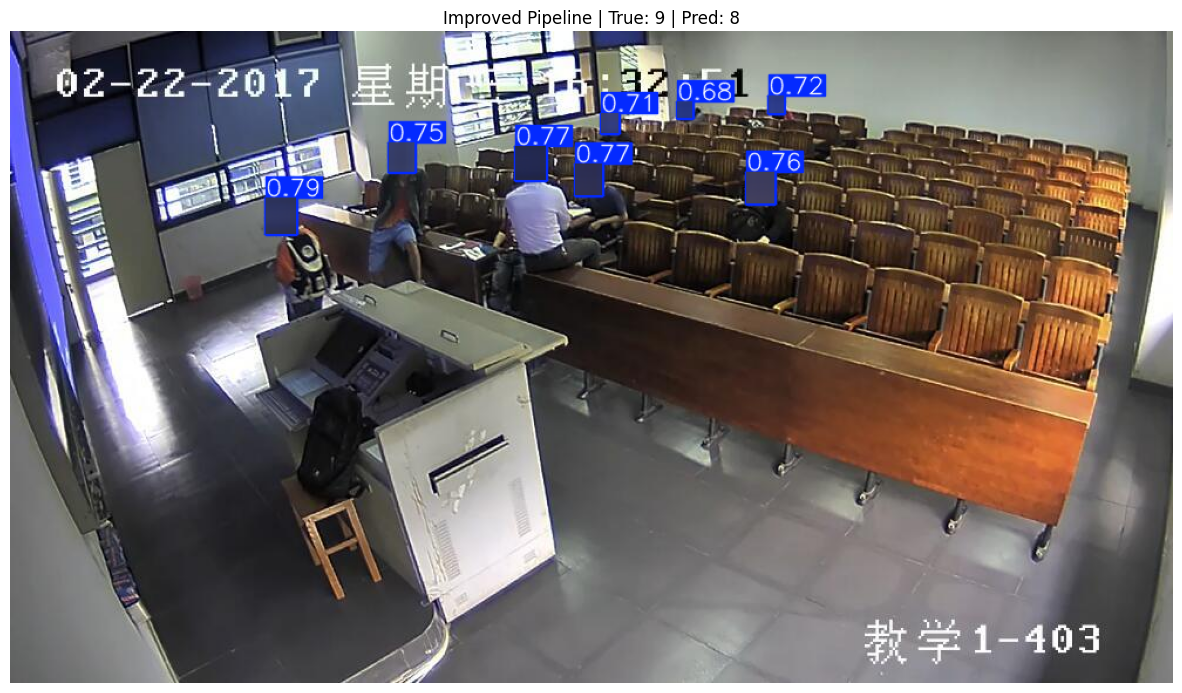

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
import cv2  # Required for image processing (blur + color conversion)

# 1. Automatically select first test image

# Search for all test images recursively inside /test folder
test_imgs = glob.glob(os.path.join(path, "test", "**", "*.jpg"), recursive=True)

# If no test images found, fallback to all_images list
if not test_imgs:
    test_imgs = all_images

# Select the first image for testing
image_path = test_imgs[0]

file_name = os.path.basename(image_path)

# 2. جلب القيمة الحقيقية (Ground Truth) من القاموس مباشرة
# بدلاً من فتح ملف الـ txt والعد يدوياً، نستخدم القاموس المُعد مسبقاً
true_count = gt_lookup.get(file_name, 0)
# Print selected image name
print("Testing on:", os.path.basename(image_path))


# 2. YOLO Prediction

# Run object detection on the selected image
results = model.predict(
    source=image_path,  # Input image path
    conf=0.25,          # Confidence threshold
    iou=0.30,           # IoU threshold for NMS
    imgsz=640           # Image size used during inference
)


# 4. Compare Results

# Count detected objects by the model
detected_count = len(results[0].boxes)

print(f"True Value : {true_count}")
print(f"Detected   : {detected_count}")

# Simple accuracy calculation (based on count comparison)
if true_count > 0:
    acc = (min(true_count, detected_count) / max(true_count, detected_count)) * 100
    print(f"Accuracy   : {acc:.2f}%")


# 5. Display image with blurred detections

# Draw bounding boxes (without labels) on the image first
res_plotted = results[0].plot(conf=True, line_width=2, labels=False)

# Extract bounding box coordinates
boxes = results[0].boxes.xyxy.cpu().numpy().astype(int)

# Apply blur to each detected bounding box region
for (x1, y1, x2, y2) in boxes:
    # Extract region of interest (ROI)
    roi = res_plotted[y1:y2, x1:x2]

    # Apply Gaussian blur to the ROI
    blurred_roi = cv2.GaussianBlur(roi, (51, 51), 30)

    # Replace original region with blurred version
    res_plotted[y1:y2, x1:x2] = blurred_roi


# 6. Show final result

plt.figure(figsize=(15, 12))

# Convert BGR (OpenCV) to RGB (matplotlib) before displaying
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))

# Display title with ground truth vs prediction
plt.title(f"Improved Pipeline | True: {true_count} | Pred: {detected_count}")

# Hide axes
plt.axis('off')

# Show image
plt.show()

## Step 6 - Evaluation


In [ ]:
import pandas as pd
import numpy as np
import time
import os
import glob

records = []
times = []

test_images = glob.glob(os.path.join(path, "test", "**", "*.jpg"), recursive=True)

for image_path in test_images:
    file_basename = os.path.basename(image_path)

    gt = gt_lookup.get(file_basename)

    if gt is None:
        continue

    start_time = time.time()
    results = model.predict(source=image_path, conf=0.25, iou=0.30, imgsz=640, verbose=False)
    detected_count = len(results[0].boxes)
    end_time = time.time()

    elapsed_time = end_time - start_time
    error = abs(gt - detected_count)

    records.append({
        'image_path': image_path,
        'file_basename': file_basename,
        'gt': gt,
        'predicted': detected_count,
        'error': error,
        'time': elapsed_time
    })
    times.append(elapsed_time)

df_results = pd.DataFrame(records)

#Evaluation Metrics

df_eval = df_results.dropna(subset=['gt', 'error']).copy()

if df_eval.empty:
    print("No ground truth available.")
else:
    preds  = df_eval['predicted'].values
    gts    = df_eval['gt'].values
    errors = df_eval['error'].values

    TP = np.sum(np.minimum(preds, gts))
    FP = np.sum(np.clip(preds - gts, 0, None))
    FN = np.sum(np.clip(gts - preds, 0, None))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    metrics = {
        "Images"         : len(df_eval),
        "MAE"            : round(float(np.mean(errors)), 2),
        "RMSE"           : round(float(np.sqrt(np.mean((preds - gts) ** 2))), 2),
        "Precision"      : round(precision, 3),
        "Recall"         : round(recall, 3),
        "F1 Score"       : round(f1, 3),
        "Accuracy (+-3)" : str(round(float(np.mean(errors <= 3) * 100), 1)) + "%",
        "Accuracy (+-5)" : str(round(float(np.mean(errors <= 5) * 100), 1)) + "%",
        "Over-count"     : int(np.sum(preds > gts)),
        "Under-count"    : int(np.sum(preds < gts)),
        "Exact match"    : int(np.sum(preds == gts)),
        "Avg time/image" : str(round(float(np.mean(times)), 3)) + " s"
    }

    print("  EVALUATION METRICS")
    for k, v in metrics.items():
        print("  " + k.ljust(18) + ": " + str(v))

  EVALUATION METRICS
  Images            : 500
  MAE               : 1.49
  RMSE              : 2.81
  Precision         : 0.971
  Recall            : 0.986
  F1 Score          : 0.979
  Accuracy (+-3)    : 87.2%
  Accuracy (+-5)    : 94.2%
  Over-count        : 163
  Under-count       : 106
  Exact match       : 231
  Avg time/image    : 0.022 s


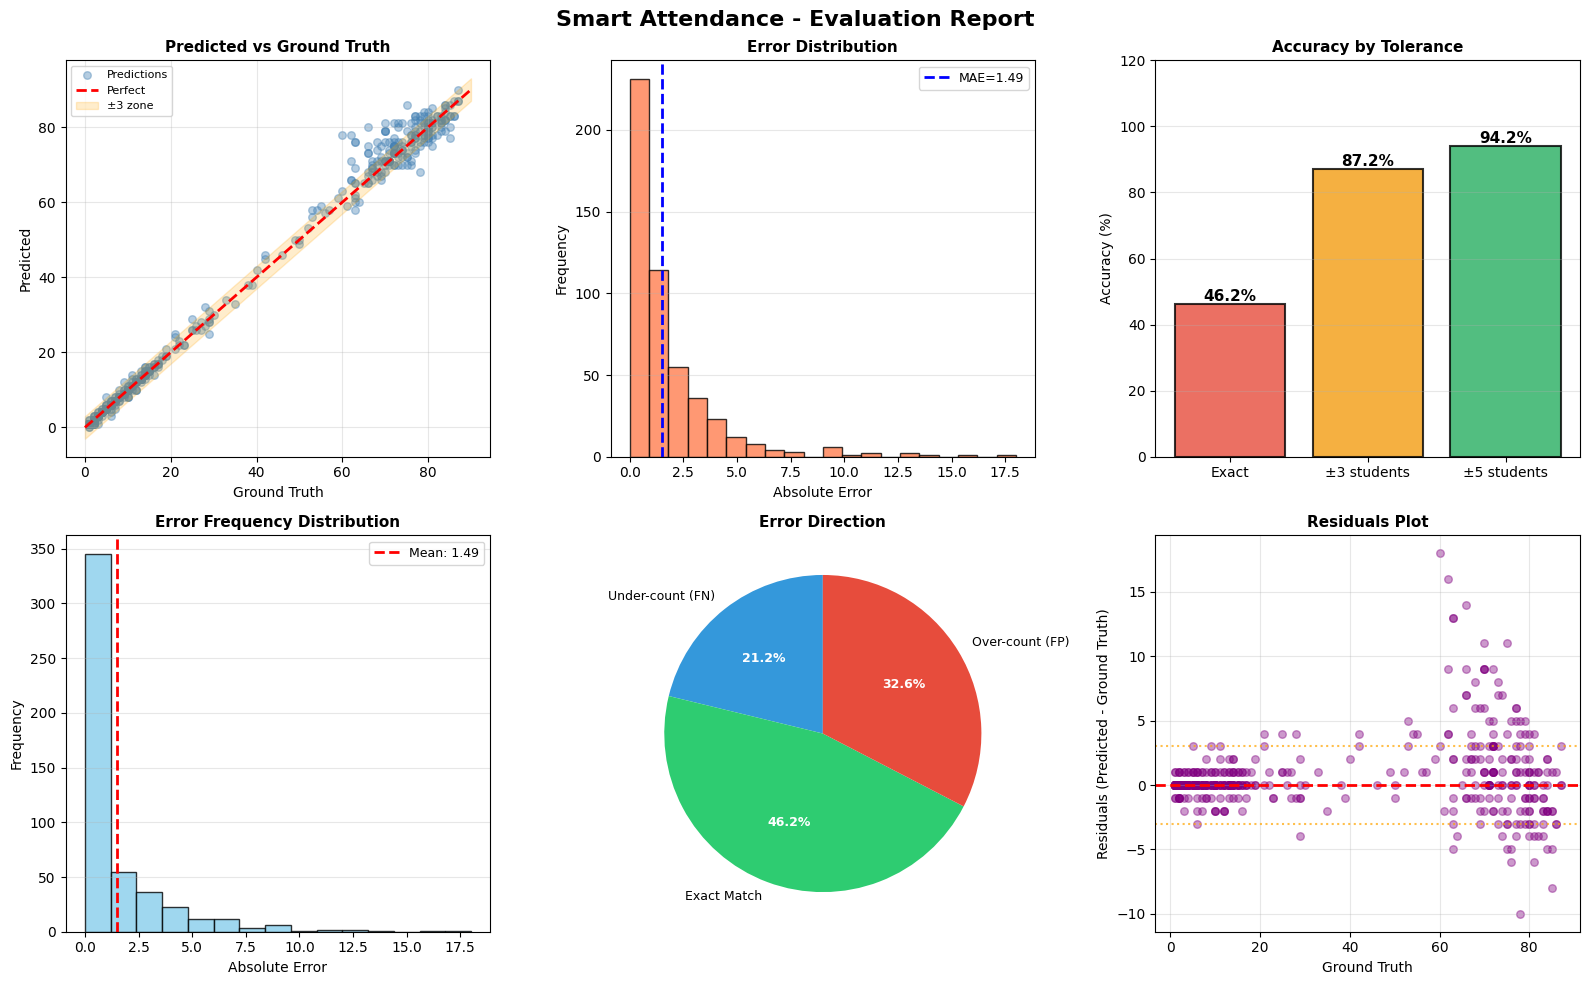

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Use actual data from df_results
# =====================================================

# Extract data from evaluation results
df_eval = df_results.dropna(subset=['gt', 'error']).copy()

# Get values from DataFrame
preds = df_eval['predicted'].values
gts = df_eval['gt'].values
errors = df_eval['error'].values
times = df_eval['time'].values

# Calculate metrics
TP = np.sum(np.minimum(preds, gts))
FP = np.sum(np.clip(preds - gts, 0, None))
FN = np.sum(np.clip(gts - preds, 0, None))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

mae = np.mean(errors)
rmse = np.sqrt(np.mean((preds - gts) ** 2))
accuracy_3 = np.mean(errors <= 3) * 100
accuracy_5 = np.mean(errors <= 5) * 100

exact_match = int(np.sum(preds == gts))
overcount = int(np.sum(preds > gts))
undercount = int(np.sum(preds < gts))
total_images = len(df_eval)

# =====================================================
# Create comprehensive evaluation report with 6 plots
# =====================================================

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Smart Attendance - Evaluation Report',
             fontsize=16, fontweight='bold', y=0.98)

# =====================================================
# 1. Predicted vs Ground Truth
# =====================================================

ax1 = plt.subplot(2, 3, 1)

ax1.scatter(gts, preds, alpha=0.4, s=30, color='steelblue', label='Predictions')

min_val = min(gts.min(), preds.min())
max_val = max(gts.max(), preds.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
ax1.fill_between([min_val, max_val], [min_val-3, max_val-3], [min_val+3, max_val+3],
                  alpha=0.2, color='orange', label='±3 zone')

ax1.set_xlabel('Ground Truth', fontsize=10)
ax1.set_ylabel('Predicted', fontsize=10)
ax1.set_title('Predicted vs Ground Truth', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# =====================================================
# 2. Error Distribution
# =====================================================

ax2 = plt.subplot(2, 3, 2)

ax2.hist(errors, bins=20, color='coral', alpha=0.8, edgecolor='black')
ax2.axvline(x=mae, color='blue', linestyle='--', linewidth=2, label=f'MAE={mae:.2f}')

ax2.set_xlabel('Absolute Error', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.set_title('Error Distribution', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# =====================================================
# 3. Accuracy by Tolerance
# =====================================================

ax3 = plt.subplot(2, 3, 3)

accuracy_exact = (exact_match / total_images) * 100

metrics_names = ['Exact', '±3 students', '±5 students']
metrics_values = [accuracy_exact, accuracy_3, accuracy_5]
colors = ['#e74c3c', '#f39c12', '#27ae60']

bars = ax3.bar(metrics_names, metrics_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax3.set_ylabel('Accuracy (%)', fontsize=10)
ax3.set_title('Accuracy by Tolerance', fontsize=11, fontweight='bold')
ax3.set_ylim([0, 120])
ax3.grid(True, alpha=0.3, axis='y')

# =====================================================
# 4. Error Frequency Distribution
# =====================================================

ax4 = plt.subplot(2, 3, 4)

ax4.hist(errors, bins=15, color='skyblue', alpha=0.8, edgecolor='black')
ax4.axvline(x=mae, color='red', linestyle='--', linewidth=2, label=f'Mean: {mae:.2f}')

ax4.set_xlabel('Absolute Error', fontsize=10)
ax4.set_ylabel('Frequency', fontsize=10)
ax4.set_title('Error Frequency Distribution', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

# =====================================================
# 5. Error Direction (Pie Chart)
# =====================================================

ax5 = plt.subplot(2, 3, 5)

error_types = ['Under-count (FN)', 'Exact Match', 'Over-count (FP)']
error_counts = [undercount, exact_match, overcount]
colors_pie = ['#3498db', '#2ecc71', '#e74c3c']

wedges, texts, autotexts = ax5.pie(error_counts, labels=error_types, autopct='%1.1f%%',
                                     colors=colors_pie, startangle=90, textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax5.set_title('Error Direction', fontsize=11, fontweight='bold')

# =====================================================
# 6. Residuals Plot
# =====================================================

ax6 = plt.subplot(2, 3, 6)

residuals = preds - gts

ax6.scatter(gts, residuals, alpha=0.4, s=30, color='purple')
ax6.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax6.axhline(y=3, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
ax6.axhline(y=-3, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)

ax6.set_xlabel('Ground Truth', fontsize=10)
ax6.set_ylabel('Residuals (Predicted - Ground Truth)', fontsize=10)
ax6.set_title('Residuals Plot', fontsize=11, fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# APPLICATION

Saving Image 2026-04-30 at 7.57.36 PM.jpeg to Image 2026-04-30 at 7.57.36 PM.jpeg


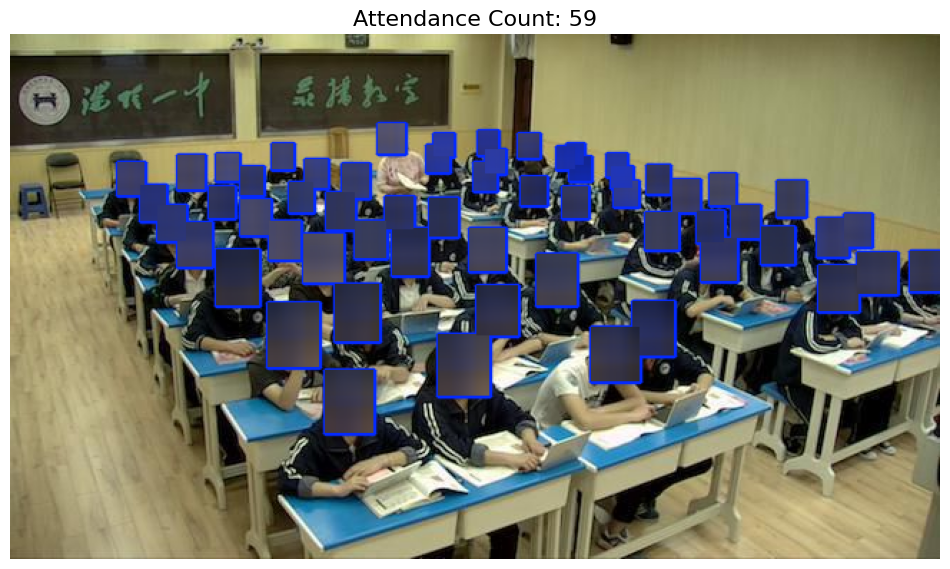

In [ ]:
#from google.colab import files
#import cv2
#import matplotlib.pyplot as plt



# Upload image from local device
uploaded = files.upload()

# Get uploaded image filename
img_path = list(uploaded.keys())[0]



# Run YOLO prediction

r = model.predict(
    source=img_path,
    conf=0.25,        # Confidence threshold
    iou=0.30,         # IoU threshold
    classes=[0],      # Only detect class 0 (head/student)
    imgsz=640,
    verbose=False
)

# Count number of detected objects
pred = len(r[0].boxes)


# Draw predictions on image
# Plot bounding boxes on image (without labels)
plotted = r[0].plot(conf=False, line_width=2, labels=False)

# Apply blur inside detected boxes

# Extract bounding box coordinates
boxes = r[0].boxes.xyxy.cpu().numpy().astype(int)

# Loop through each detected box
for (x1, y1, x2, y2) in boxes:

    # Extract region of interest (ROI)
    roi = plotted[y1:y2, x1:x2]

    # Apply Gaussian blur to anonymize detected region
    blurred_roi = cv2.GaussianBlur(roi, (51, 51), 30)

    # Replace original region with blurred version
    plotted[y1:y2, x1:x2] = blurred_roi



# Display final output

plt.figure(figsize=(12, 8))

# Convert BGR (OpenCV) to RGB (Matplotlib)
plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))

# Show detected count
plt.title(f"Attendance Count: {pred}", fontsize=16)

# Hide axis
plt.axis('off')

# Show image
plt.show()